
#**Empazar a trabajar con Pandas**


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import sys
sys.path.append("/content/drive/MyDrive/utils")

from colab_git import setup, push

setup(
    project_dir="/content/drive/MyDrive/Colab Notebooks/Libro_Python_para_analisis_de_datos",
    repo="data_analyst",
)

Mounted at /content/drive
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import numpy as np
import pandas as pd

In [4]:
from pandas import Series as SR
from pandas import DataFrame as DF

##**Introducción a las estructuras de datos de pandas**

###**Series**
son un objeto unidimencional, lo que seria a un array en numpy a diferencia que si puede contener elemetos de distinto tipo (`str`, `int`, `float`, ...)




In [5]:
obj = SR([4, '7', -5, 3])
print(f'''obj:
{obj}
''')
print(f'''
obj.index:
{obj.index}
tipo del elemento[0]
{type(obj[0])}
tipo del elemento[1]
{type(obj[1])}
''')
print(f'''
obj.values:
{obj.values}
''')
#creando una serie con indeces
obj2 = SR([4, 7, -5, 3], index=['d', 'b', 'a', 'c'])
print(f'''
obj2:
{obj2}
''')

obj:
0     4
1     7
2    -5
3     3
dtype: object


obj.index:
RangeIndex(start=0, stop=4, step=1)
tipo del elemento[0]
<class 'int'>
tipo del elemento[1]
<class 'str'>


obj.values:
[4 '7' -5 3]


obj2:
d    4
b    7
a   -5
c    3
dtype: int64



In [6]:
# aca vemos como numpy solo acepta un solo tipo para los valores de sus arrays
arr = np.array([1, '2', 3, 4])
print(f'''
arr:
{arr}
''')
print(f'''
arr.dtype:
{type(arr[2])}
''')


arr:
['1' '2' '3' '4']


arr.dtype:
<class 'numpy.str_'>



In [7]:
# ademas se puede devolver los valores de las series tal cual, un diccionario con los indeces
print(f'''
obj2['a']:
{obj2['a']}
''')

print(f'''
obj2[['c', 'a', 'd']]:
{obj2[['c', 'b', 'd']]}
''')


obj2['a']:
-5


obj2[['c', 'a', 'd']]:
c    3
b    7
d    4
dtype: int64



In [8]:
# uso de condicioneles
print(f'''obj2[obj2 > 0]:
{obj2[obj2 > 0]}
''')

# multiplicacion con escalare
print(f'''
obj2 * 2:
{obj2 * 2}
''')

# aplicacion de funciones
print(f'''
np.exp(obj2):
{np.exp(obj2)}
''')

obj2[obj2 > 0]:
d    4
b    7
c    3
dtype: int64


obj2 * 2:
d     8
b    14
a   -10
c     6
dtype: int64


np.exp(obj2):
d      54.598150
b    1096.633158
a       0.006738
c      20.085537
dtype: float64



In [9]:
# para saber si un indece es contenido dentro de la serie
print(f'''"a" in obj2:
{"a" in obj2}
''')
print(f'''"f" in obj2:
{"f" in obj2}
''')

"a" in obj2:
True

"f" in obj2:
False



In [10]:
# creando series a partir de diccionarios
sdata = {"Ohio": 35000, "Texas": 71000, "Oregon": 16000, "Utah": 5000}
obj3 = pd.Series(sdata)
print(f'''obj3:
{obj3}
''')

obj3:
Ohio      35000
Texas     71000
Oregon    16000
Utah       5000
dtype: int64



In [11]:
# transformar una serie en un diccionario
obj3_dict = obj3.to_dict()
print(f'''obj3_dict():
{obj3_dict}
''')
print(f'''type(obj3_dict):
{type(obj3_dict)}
''')

# si paso un lista de indeces va tomar los valores que esten en los key del diccionario y lo que no esten en la lista los eliminara
states = ['California', 'Ohio', 'Oregon', 'Texas']
obj4 =pd.Series(obj3_dict, index=states)
print(f'''obj4:
{obj4}
''')

obj3_dict():
{'Ohio': 35000, 'Texas': 71000, 'Oregon': 16000, 'Utah': 5000}

type(obj3_dict):
<class 'dict'>

obj4:
California        NaN
Ohio          35000.0
Oregon        16000.0
Texas         71000.0
dtype: float64



In [12]:
# para saber si hay elementos faltante o no
print(f'''pd.isnull(obj4):
{pd.isna(obj4)}
''')
print(f'''pd.notnull(obj4):
{pd.notna(obj4)}
''')
# o tambien
print(f'''obj4.isna()):
{obj4.isna()}
''')
print(f'''obj4.notna():
{obj4.notna()}
''')

pd.isnull(obj4):
California     True
Ohio          False
Oregon        False
Texas         False
dtype: bool

pd.notnull(obj4):
California    False
Ohio           True
Oregon         True
Texas          True
dtype: bool

obj4.isna()):
California     True
Ohio          False
Oregon        False
Texas         False
dtype: bool

obj4.notna():
California    False
Ohio           True
Oregon         True
Texas          True
dtype: bool



In [13]:
print(f'''obj3:
{obj3}
''')
print(f'''obj4:
{obj4}
''')
# operaciones aritmeticas de series
print(f'''obj3 + obj4:
{obj3 + obj4}
''')


obj3:
Ohio      35000
Texas     71000
Oregon    16000
Utah       5000
dtype: int64

obj4:
California        NaN
Ohio          35000.0
Oregon        16000.0
Texas         71000.0
dtype: float64

obj3 + obj4:
California         NaN
Ohio           70000.0
Oregon         32000.0
Texas         142000.0
Utah               NaN
dtype: float64



In [14]:
# atributo .name .index
obj4.name = 'population'
obj4.index.name = 'state'
print(f'''obj4:
{obj4}
''')
obj4
print(f'''obj original
{obj}
''')
obj.index = ['Bob', 'Steve', 'Jeff', 'Ryan']
print(f'''obj con indices modificados:
{obj}
''')

obj4:
state
California        NaN
Ohio          35000.0
Oregon        16000.0
Texas         71000.0
Name: population, dtype: float64

obj original
0     4
1     7
2    -5
3     3
dtype: object

obj con indices modificados:
Bob       4
Steve     7
Jeff     -5
Ryan      3
dtype: object



###**DataFrame**

In [15]:
# creacion de dataframe
data = {
    'state': ['Ohio', 'Ohio', 'Ohio', 'Nevada', 'Nevada', 'Nevada'],
    'year': [2000, 2001, 2002, 2001, 2002, 2003],
    'pop': [1.5, 1.7, 3.6, 2.4, 2.9, 3.2],
}
df = pd.DataFrame(data)
df.name = 'state vs populations'
df

,state,year,pop
0,Ohio,2000,1.5
1,Ohio,2001,1.7
2,Ohio,2002,3.6
3,Nevada,2001,2.4
4,Nevada,2002,2.9
5,Nevada,2003,3.2


In [16]:
# metodos head()
df.head()

,state,year,pop
0,Ohio,2000,1.5
1,Ohio,2001,1.7
2,Ohio,2002,3.6
3,Nevada,2001,2.4
4,Nevada,2002,2.9


In [17]:
# metodo tail()
df.tail()

,state,year,pop
1,Ohio,2001,1.7
2,Ohio,2002,3.6
3,Nevada,2001,2.4
4,Nevada,2002,2.9
5,Nevada,2003,3.2


In [18]:
# como disponer las columnas en un orden
df_copy = df.reindex(columns=['year', 'state', 'pop'])
df_copy

,year,state,pop
0,2000,Ohio,1.5
1,2001,Ohio,1.7
2,2002,Ohio,3.6
3,2001,Nevada,2.4
4,2002,Nevada,2.9
5,2003,Nevada,3.2


In [19]:
# si se pasa mas de una columna se rellenara con NaN
df_copy = df.reindex(columns=['year', 'state', 'pop', 'debt'])
df_copy.columns

Index(['year', 'state', 'pop', 'debt'], dtype='object')

In [20]:
# como obtener una columna
df['state']

# o con notacion de .
df.year


,year
0,2000
1,2001
2,2002
3,2001
4,2002
5,2003


In [21]:
# como obtener una fila
df.iloc[1]
df.loc[1]

,1
state,Ohio
year,2001
pop,1.7


In [22]:
# asignacion de valores escalares a columna
df_copy.debt = 16.5
df_copy

# asignacion de valores lista a un columna

df_copy.debt = np.arange(1., 12., 2)

df_copy

,year,state,pop,debt
0,2000,Ohio,1.5,1.0
1,2001,Ohio,1.7,3.0
2,2002,Ohio,3.6,5.0
3,2001,Nevada,2.4,7.0
4,2002,Nevada,2.9,9.0
5,2003,Nevada,3.2,11.0


In [23]:
# la asinacion de valores deben coincidir los indices con los indeces del dataframe
val = pd.Series([-1.2, -1.5, -1.7], index=[2, 4, 5])
df["debt"] = val
df

,state,year,pop,debt
0,Ohio,2000,1.5,NaN
1,Ohio,2001,1.7,NaN
2,Ohio,2002,3.6,-1.2
3,Nevada,2001,2.4,NaN
4,Nevada,2002,2.9,-1.5
5,Nevada,2003,3.2,-1.7


In [24]:
# es recomendable usar la notacion [''] en vez de . para la asignacion de valores
df['eastern'] = df.state == 'Ohio'
df

,state,year,pop,debt,eastern
0,Ohio,2000,1.5,NaN,True
1,Ohio,2001,1.7,NaN,True
2,Ohio,2002,3.6,-1.2,True
3,Nevada,2001,2.4,NaN,False
4,Nevada,2002,2.9,-1.5,False
5,Nevada,2003,3.2,-1.7,False


In [25]:
# la funcion del sirve para eliminar una columna
del df['eastern']
df.columns

Index(['state', 'year', 'pop', 'debt'], dtype='object')

In [26]:
# copiar una columna del dataframe
df_state = df['state'].copy()
df_state[0]='florida'

si se copia el df `df_state = df['state']` no resulta en una copia sino en un reflejo de la columna `state`

In [27]:
# creacion de dataframe con dictionarios anidados
populations = {
  "Ohio": {
    2000: 1.5,
    2001: 1.7,
    2002: 3.6
    },
  "Nevada": {
    2001: 2.4,
    2002: 2.9
    }
}

df_3 = pd.DataFrame(populations)
df_3

,Ohio,Nevada
2000,1.5,NaN
2001,1.7,2.4
2002,3.6,2.9


In [28]:
# transponer un dataframe
df_3.T

,2000,2001,2002
Ohio,1.5,1.7,3.6
Nevada,NaN,2.4,2.9


al transponer un dataframe si contiene un dato tipo object se transformaran en datos tipo object

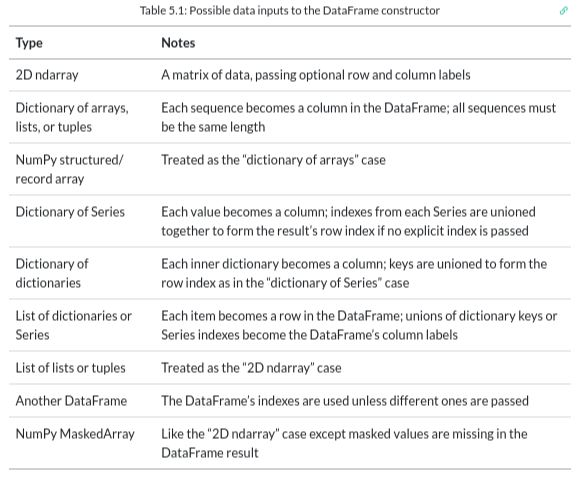

a diferencia de la Series los DataFrames no poseen atributo name

In [29]:
#  establecer nombre de los index
df_3.index.name = 'year'
df_3.columns.name = 'state'
df_3

state,Ohio,Nevada
year,,
2000,1.5,NaN
2001,1.7,2.4
2002,3.6,2.9


In [30]:
# transformar un dataframe a un Ndarray
df_3.to_numpy()

array([[1.5, nan],
       [1.7, 2.4],
       [3.6, 2.9]])

In [31]:
df.to_numpy()

array([['Ohio', 2000, 1.5, nan],
       ['Ohio', 2001, 1.7, nan],
       ['Ohio', 2002, 3.6, -1.2],
       ['Nevada', 2001, 2.4, nan],
       ['Nevada', 2002, 2.9, -1.5],
       ['Nevada', 2003, 3.2, -1.7]], dtype=object)

###**Objetos indices**
son cualquier objeto array o conjunto que contiene las indices o etiquetas de los ejes de un dataframe


In [32]:
# construyendo un objeto indice
obj = pd.Series(np.arange(3), index=['a',' b','c'])
index = obj.index
index

Index(['a', ' b', 'c'], dtype='object')

In [33]:
# los indeces son inmutables
# index[1] = 'v'

In [34]:
print(df_3.columns)
'Ohio' in df_3.columns

Index(['Ohio', 'Nevada'], dtype='object', name='state')


True

In [35]:
print(df_3.index)
2003 in df_3.index

Index([2000, 2001, 2002], dtype='int64', name='year')


False

In [36]:
# a diferencia de los conjuntos en python, un indice de pandas puede contener items duplicados
dup_labels = pd.Index(['foo','foo','bar','bar'])
dup_labels

Index(['foo', 'foo', 'bar', 'bar'], dtype='object')

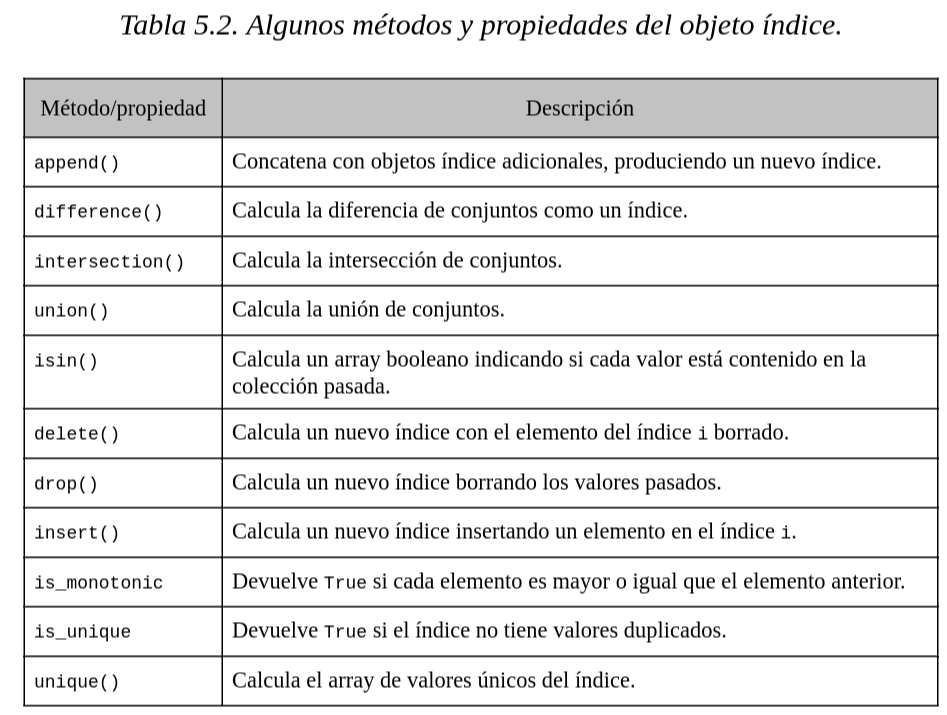

##**Funcionalidad esencial**

###**Reindexacion**
reorganiza los elementos del la serie o dataframe segun el indice

In [37]:
obj = pd.Series([4.5, 7.2, -5.3, 3.6], index=['d', 'b', 'a', 'c'])
obj.reindex(['a', 'b', 'c', 'd', 'e'])


,0
a,-5.3
b,7.2
c,3.6
d,4.5
e,NaN


In [38]:
# interpolar valores de series temporales con reindex y el method='ffill'
obj3 = pd.Series(['blue', 'purple', 'yellow'], index=[0, 2, 4])
obj3.reindex(range(6), method='ffill')

,0
0,blue
1,blue
2,purple
3,purple
4,yellow
5,yellow


In [39]:
frame = pd.DataFrame(np.arange(9).reshape((3, 3)),
                     index=["a", "c", "d"],
                     columns=["Ohio", "Texas", "California"])
print(frame)

frame2 = frame.reindex(index=["a", "b", "c", "d"])
frame2

   Ohio  Texas  California
a     0      1           2
c     3      4           5
d     6      7           8


,Ohio,Texas,California
a,0.0,1.0,2.0
b,NaN,NaN,NaN
c,3.0,4.0,5.0
d,6.0,7.0,8.0


In [40]:
# reindexando las columnas
states = ["Texas", "Utah", "California"]
frame.reindex(columns=states)

,Texas,Utah,California
a,1,NaN,2
c,4,NaN,5
d,7,NaN,8


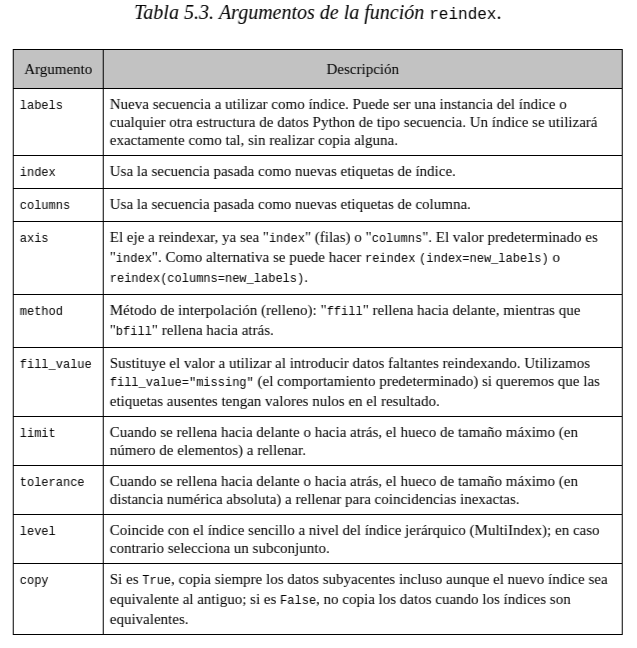

In [41]:
# reindexacion con loc
frame.loc[['a', 'c', 'd'], ['California', 'Texas']]

,California,Texas
a,2,1
c,5,4
d,8,7


###**Eliminar entradas de un eje**

In [42]:
obj = pd.Series(np.arange(5.), index=['a', 'b', 'c', 'd', 'e'])
# aca se crea un nuevo objeto para ver reflejado la eliminacion de los indices
new_obj = obj.drop('c')
new_obj = obj.drop(['d', 'c'])
# para eliminar directo en el objeto se usa el argumento inplace
obj.drop('c', inplace=True)

In [43]:
# con dataframe
data = pd.DataFrame(np.arange(16).reshape((4, 4)),
                    index=['Ohio', 'Colorado', 'Utah', 'New York'],
                    columns=['one', 'two', 'three', 'four'])
data

,one,two,three,four
Ohio,0,1,2,3
Colorado,4,5,6,7
Utah,8,9,10,11
New York,12,13,14,15


In [44]:
data.drop(['Colorado', 'Ohio'])

,one,two,three,four
Utah,8,9,10,11
New York,12,13,14,15


In [45]:
# para eliminar columnas
data.drop(columns=['two', 'three'])

,one,four
Ohio,0,3
Colorado,4,7
Utah,8,11
New York,12,15


###**Indexación, selección y filtrado**

In [46]:
# filtrado en series
obj = pd.Series(np.arange(4.), index=['a', 'b', 'c', 'd'])
# por slicing
print(f'''obj[2:3]:
{obj[2:3]}
''')
# por posicion de iloc (indices numerios)
print(f'''obj.iloc[[1,3]]:
{obj.iloc[[1,3]]}
''')
# por index
print(f'''obj[["a","c","b"]]:
{obj[["a","c","b"]]}
''')
# por condicion
print(f'''obj[obj < 2]:
{obj[obj < 2]}
''')
# por posicion de loc (indices string)
obj2 = pd.Series([1, 2, 3], index=["a", "b", "c"])
print(f'''obj2.loc[['c','a']]):
{obj2.loc[['c','a']]}
''')
# slicing con .loc
print(f'''obj2.loc['a':'c']:
{obj2.loc['a':'c']}
''')
# booleano por condicion
print(f'''obj2<3:
{obj2<3}
''')

obj[2:3]:
c    2.0
dtype: float64

obj.iloc[[1,3]]:
b    1.0
d    3.0
dtype: float64

obj[["a","c","b"]]:
a    0.0
c    2.0
b    1.0
dtype: float64

obj[obj < 2]:
a    0.0
b    1.0
dtype: float64

obj2.loc[['c','a']]):
c    3
a    1
dtype: int64

obj2.loc['a':'c']:
a    1
b    2
c    3
dtype: int64

obj2<3:
a     True
b     True
c    False
dtype: bool



In [47]:
# Ahora con dataframe
data = pd.DataFrame(np.arange(16).reshape((4, 4)),
                    index=['Ohio', 'Colorado', 'Utah', 'New York'],
                    columns=['one', 'two', 'three', 'four'])
print(f'''data:
{data}
''')
# por columna
print(f'''data['two']:
{data['two']}
''')
# por columnas
print(f'''data[['three', 'one']]:
{data[['three', 'one']]}
''')
# por slicing
print(f'''data[:2]:
{data[:2]}
''')
# por condicion
print(f'''data[data['three'] > 5]:
{data[data['three'] > 9]}
''')
# booleano por condicion
print(f'''data < 5:
{data <= 5}
''')

data:
          one  two  three  four
Ohio        0    1      2     3
Colorado    4    5      6     7
Utah        8    9     10    11
New York   12   13     14    15

data['two']:
Ohio         1
Colorado     5
Utah         9
New York    13
Name: two, dtype: int64

data[['three', 'one']]:
          three  one
Ohio          2    0
Colorado      6    4
Utah         10    8
New York     14   12

data[:2]:
          one  two  three  four
Ohio        0    1      2     3
Colorado    4    5      6     7

data[data['three'] > 5]:
          one  two  three  four
Utah        8    9     10    11
New York   12   13     14    15

data < 5:
            one    two  three   four
Ohio       True   True   True   True
Colorado   True   True  False  False
Utah      False  False  False  False
New York  False  False  False  False



###**loc iloc**

In [48]:
print(f'''data:
{data}
''')
# seleccionar una fila
print(f'''data.loc['Colorado']:
{data.loc['Colorado']}
''')
# seleccionar varias filas
print(f'''data.loc[['Colorado', 'New York']]:
{data.loc[['Colorado', 'New York']]}
''')
# seleccionar una fila y varias columnas
print(f'''data.loc['Colorado', ['two', 'three']]:
{data.loc['Colorado', ['two', 'three']]}
''')
# seleccionar un segmento de filas
print(f'''data.loc[:'Utah', 'two']:
{data.loc[:'Utah', 'two']}
''')
# seleccionar un segmento de filas y columnas
print(f'''data.loc[:'Utah', 'two':]:
{data.loc[:'Utah', 'two':]}
''')
# booleano por condicion
print(f'''data.three > 5:
{data.three > 5}
''')
# seleccionar un segmento con condicion
print(f'''data.loc['Colorado':, 'three':][data.three > 5]:
{data.loc['Colorado':, 'three':][data.three > 5]}
''')
# seleccion con at
print(f'''data.at['Colorado', 'two']:
{data.at['Colorado', 'two']}
''')

data:
          one  two  three  four
Ohio        0    1      2     3
Colorado    4    5      6     7
Utah        8    9     10    11
New York   12   13     14    15

data.loc['Colorado']:
one      4
two      5
three    6
four     7
Name: Colorado, dtype: int64

data.loc[['Colorado', 'New York']]:
          one  two  three  four
Colorado    4    5      6     7
New York   12   13     14    15

data.loc['Colorado', ['two', 'three']]:
two      5
three    6
Name: Colorado, dtype: int64

data.loc[:'Utah', 'two']:
Ohio        1
Colorado    5
Utah        9
Name: two, dtype: int64

data.loc[:'Utah', 'two':]:
          two  three  four
Ohio        1      2     3
Colorado    5      6     7
Utah        9     10    11

data.three > 5:
Ohio        False
Colorado     True
Utah         True
New York     True
Name: three, dtype: bool

data.loc['Colorado':, 'three':][data.three > 5]:
          three  four
Colorado      6     7
Utah         10    11
New York     14    15

data.at['Colorado', 'two']:
5



/tmp/ipykernel_5744/3094828166.py:30: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  {data.loc['Colorado':, 'three':][data.three > 5]}


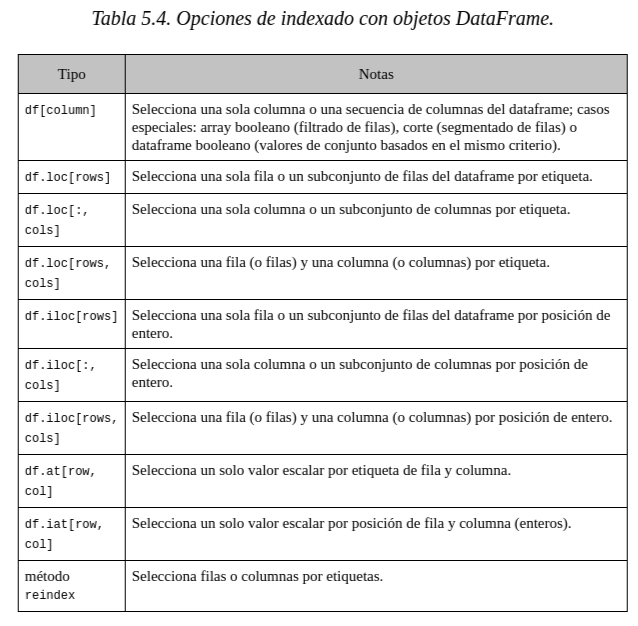

es preferibles siempre aplicar indexados o slicing de series o dataframe con `dataframe.loc` e `dataframe.iloc` en vez de `dataframe[]`

In [49]:
data[data < 5] = 0
data.loc[:, 'one'] = 1
data.iloc[2] =5
data.loc[data['four'] > 5] = 3
print(data)
data.loc[data.three == 5, 'three'] = 6
data

          one  two  three  four
Ohio        1    0      0     0
Colorado    3    3      3     3
Utah        5    5      5     5
New York    3    3      3     3


,one,two,three,four
Ohio,1,0,0,0
Colorado,3,3,3,3
Utah,5,5,6,5
New York,3,3,3,3


###**Aritmética y alineación de datos**

In [50]:
s1 = pd.Series([7.3, -2.5, 3.4, 1.5], index=["a", "c", "d", "e"])
s2 = pd.Series([-2.1, 3.6, -1.5, 4, 3.1], index=["a", "c", "e", "f", "g"])

In [51]:
# suma de productos
s1 + s2

,0
a,5.2
c,1.1
d,NaN
e,0.0
f,NaN
g,NaN


In [52]:
df1 = pd.DataFrame(np.arange(9.).reshape((3, 3)), columns=list("bcd"),
                   index=["Ohio", "Texas", "Colorado"])
df2 = pd.DataFrame(np.arange(12.).reshape((4, 3)), columns=list("bde"),
                   index=["Utah", "Ohio", "Texas", "Oregon"])

In [53]:
# suma de dataframes
df1 + df2

,b,c,d,e
Colorado,NaN,NaN,NaN,NaN
Ohio,3.0,NaN,6.0,NaN
Oregon,NaN,NaN,NaN,NaN
Texas,9.0,NaN,12.0,NaN
Utah,NaN,NaN,NaN,NaN


notese que en ambos casos, tanto en series como en dataframes solo se suman los indices que coincidan y en el caso de dataframes tambien las columnas

###Métodos aritméticos con valores de relleno


In [54]:
df1 = pd.DataFrame(np.arange(12.).reshape((3, 4)),
                   columns=list("abcd"))
df2 = pd.DataFrame(np.arange(20.).reshape((4, 5)),
                   columns=list("abcde"))
df2.loc[1,'b'] = np.nan
print(f'''df1:
{df1}

df2
{df2}
''')

df1:
     a    b     c     d
0  0.0  1.0   2.0   3.0
1  4.0  5.0   6.0   7.0
2  8.0  9.0  10.0  11.0

df2
      a     b     c     d     e
0   0.0   1.0   2.0   3.0   4.0
1   5.0   NaN   7.0   8.0   9.0
2  10.0  11.0  12.0  13.0  14.0
3  15.0  16.0  17.0  18.0  19.0



In [55]:
df1+df2

,a,b,c,d,e
0,0.0,2.0,4.0,6.0,NaN
1,9.0,NaN,13.0,15.0,NaN
2,18.0,20.0,22.0,24.0,NaN
3,NaN,NaN,NaN,NaN,NaN


In [56]:
# para sumar y agregar valores entre dataframes .add()
df1.add(df2, fill_value=0)

,a,b,c,d,e
0,0.0,2.0,4.0,6.0,4.0
1,9.0,5.0,13.0,15.0,9.0
2,18.0,20.0,22.0,24.0,14.0
3,15.0,16.0,17.0,18.0,19.0


In [57]:
df1.rdiv(1) # 1/df1
df1.radd(df2, fill_value=0)


,a,b,c,d,e
0,0.0,2.0,4.0,6.0,4.0
1,9.0,5.0,13.0,15.0,9.0
2,18.0,20.0,22.0,24.0,14.0
3,15.0,16.0,17.0,18.0,19.0


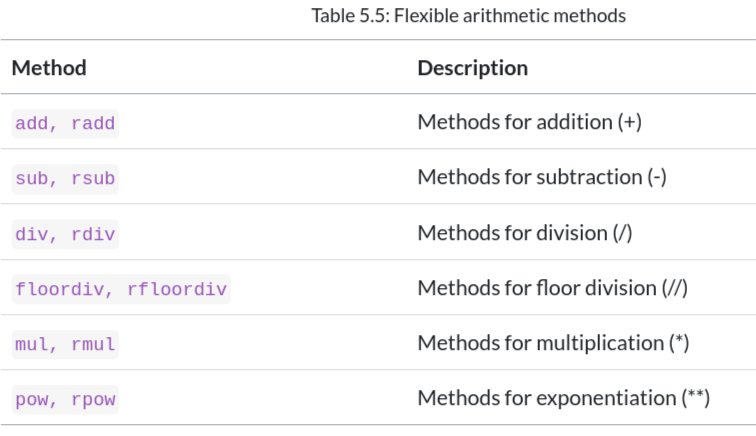

Operaciones entre objetos DataFrame y Series

In [58]:
frame = pd.DataFrame(np.arange(12.).reshape((4, 3)),
                     columns=list("bde"),
                     index=["Utah", "Ohio", "Texas", "Oregon"])
series = frame.iloc[0]
# resta donde coinciden las columnas del df con el indice de las serie
print(f'''frame:
{frame}

series:
{series}
''')
print(f'''frame - series:
{frame - series}
''')


frame:
          b     d     e
Utah    0.0   1.0   2.0
Ohio    3.0   4.0   5.0
Texas   6.0   7.0   8.0
Oregon  9.0  10.0  11.0

series:
b    0.0
d    1.0
e    2.0
Name: Utah, dtype: float64

frame - series:
          b    d    e
Utah    0.0  0.0  0.0
Ohio    3.0  3.0  3.0
Texas   6.0  6.0  6.0
Oregon  9.0  9.0  9.0



In [59]:
# suma de dataframe y serie (indexa los valores que no coinciden o no estan)
serie2 = pd.Series(range(3), index=["b", "e", "f"])
print(f'''frame:
{frame}

series:
{serie2}
''')
print(f'''frame + series:
{frame + serie2}
''')

frame:
          b     d     e
Utah    0.0   1.0   2.0
Ohio    3.0   4.0   5.0
Texas   6.0   7.0   8.0
Oregon  9.0  10.0  11.0

series:
b    0
e    1
f    2
dtype: int64

frame + series:
          b   d     e   f
Utah    0.0 NaN   3.0 NaN
Ohio    3.0 NaN   6.0 NaN
Texas   6.0 NaN   9.0 NaN
Oregon  9.0 NaN  12.0 NaN



In [60]:
# resta cuando coinciden los indices del dataframe y la serie
serie3 = frame["d"]
print(f'''frame:
{frame}

series:
{serie3}
''')
print(f'''frame.sub(serie3, axis='index'):
{frame.sub(serie3, axis='index')}
''')




frame:
          b     d     e
Utah    0.0   1.0   2.0
Ohio    3.0   4.0   5.0
Texas   6.0   7.0   8.0
Oregon  9.0  10.0  11.0

series:
Utah       1.0
Ohio       4.0
Texas      7.0
Oregon    10.0
Name: d, dtype: float64

frame.sub(serie3, axis='index'):
          b    d    e
Utah   -1.0  0.0  1.0
Ohio   -1.0  0.0  1.0
Texas  -1.0  0.0  1.0
Oregon -1.0  0.0  1.0



###**Aplicación y asignación de funciones**
las *ufuncs* de numpy funcionan tambien con los dataframe de pandas

In [61]:
frame = pd.DataFrame(np.random.standard_normal((4, 3)),
                     columns=list("bde"),
                     index=["Utah", "Ohio", "Texas", "Oregon"])
print(f'''frame:
{frame}

np.abs(frame)
{np.abs(frame)}
''')

frame:
               b         d         e
Utah   -0.862579  0.098787 -0.051458
Ohio    0.644434  0.946992  0.595697
Texas   1.484816  0.988368  1.314993
Oregon  1.452772 -0.321828 -0.307320

np.abs(frame)
               b         d         e
Utah    0.862579  0.098787  0.051458
Ohio    0.644434  0.946992  0.595697
Texas   1.484816  0.988368  1.314993
Oregon  1.452772  0.321828  0.307320



In [62]:
# metodo apply
f = lambda x: x.max() - x.min()
f2= lambda x: x.max()
format = lambda x: "%.2f" % x
print(f'''frame:
{frame}

frame.apply(f)
{frame.apply(f)}
''')
# apply con el argumento axis
print(f'''
frame.apply(f2, axis='columns')
{frame.apply(f2, axis='columns')}
''')

# cuando pasamos una funcion que devuelve una serie a la funcion apply
def f(x):
    return pd.Series([x.min(), x.max()], index=["min", "max"])
print(f'''
frame.apply(f)
{frame.apply(f)}
''')

# ahora con el argumento axis
print(f'''
frame.apply(f, axis='columns')
{frame.apply(f, axis='columns')}
''')

frame:
               b         d         e
Utah   -0.862579  0.098787 -0.051458
Ohio    0.644434  0.946992  0.595697
Texas   1.484816  0.988368  1.314993
Oregon  1.452772 -0.321828 -0.307320

frame.apply(f)
b    2.347395
d    1.310196
e    1.622312
dtype: float64


frame.apply(f2, axis='columns')
Utah      0.098787
Ohio      0.946992
Texas     1.484816
Oregon    1.452772
dtype: float64


frame.apply(f)
            b         d         e
min -0.862579 -0.321828 -0.307320
max  1.484816  0.988368  1.314993


frame.apply(f, axis='columns')
             min       max
Utah   -0.862579  0.098787
Ohio    0.595697  0.946992
Texas   0.988368  1.484816
Oregon -0.321828  1.452772



In [63]:
# applymap
format = lambda x: "%.2f" % x
print(f'''
frame.applymap(format)
{frame.map(format)}
''')


frame.applymap(format)
            b      d      e
Utah    -0.86   0.10  -0.05
Ohio     0.64   0.95   0.60
Texas    1.48   0.99   1.31
Oregon   1.45  -0.32  -0.31



### **Ordenación y asignación de rangos**


In [64]:
# para series
obj = pd.Series(np.arange(4), index=["d", "a", "b", "c"])
obj

,0
d,0
a,1
b,2
c,3


In [65]:
# ordenamiento por indece
obj.sort_index()

,0
a,1
b,2
c,3
d,0


In [66]:
# para dataframe
frame = pd.DataFrame(np.arange(8).reshape((2, 4)),
                     index=["three", "one"],
                     columns=["d", "a", "b", "c"])
frame

,d,a,b,c
three,0,1,2,3
one,4,5,6,7


In [67]:
# ordenamiento por columna
frame.sort_index(axis='columns')

,a,b,c,d
three,1,2,3,0
one,5,6,7,4


In [68]:
# de forma desendente
frame.sort_index(axis='columns', ascending=False)

,d,c,b,a
three,0,3,2,1
one,4,7,6,5


In [69]:
# ordenamiento de serie por valores
obj = pd.Series([4, 7, -3, 2])
obj.sort_values()

,0
2,-3
3,2
0,4
1,7


In [70]:
# los valores faltantes en el ordenamiento quedan al final
obj = pd.Series([4, np.nan, 7, np.nan, -3, 2])
obj.sort_values()

,0
4,-3.0
5,2.0
0,4.0
2,7.0
1,NaN
3,NaN


In [71]:
# para que los valores faltantes se orden al principio
obj.sort_values(na_position="first")

,0
1,NaN
3,NaN
4,-3.0
5,2.0
0,4.0
2,7.0


In [72]:
# ordenamiento de dataframe por 1 o varias columnas
frame = pd.DataFrame({"b": [4, 7, -3, 2,3], "a": [0, 1, 0, 1,1]})
frame

,b,a
0,4,0
1,7,1
2,-3,0
3,2,1
4,3,1


In [73]:
# por una columna
frame.sort_values(by="b")

,b,a
2,-3,0
3,2,1
4,3,1
0,4,0
1,7,1


In [74]:
# por varias columnas
frame.sort_values(by=["a", "b"])

,b,a
2,-3,0
0,4,0
3,2,1
4,3,1
1,7,1


In [75]:
# metodo rank sirve para asignarle un valor de 1 en adelante a los valores de la serie o dataframe
frame = pd.DataFrame({"b": [4.3, 7, -3, 2], "a": [0, 1, 0, 1], "c": [-2, 5, 8, -2.5]})
print(frame)
print(frame.rank(method='first'))
frame

     b  a    c
0  4.3  0 -2.0
1  7.0  1  5.0
2 -3.0  0  8.0
3  2.0  1 -2.5
     b    a    c
0  3.0  1.0  2.0
1  4.0  3.0  3.0
2  1.0  2.0  4.0
3  2.0  4.0  1.0


,b,a,c
0,4.3,0,-2.0
1,7.0,1,5.0
2,-3.0,0,8.0
3,2.0,1,-2.5


In [76]:
obj = pd.Series([7, -5, 7, 4, 2, 0, 4])
print(obj)
obj.rank()

0    7
1   -5
2    7
3    4
4    2
5    0
6    4
dtype: int64


,0
0,6.5
1,1.0
2,6.5
3,4.5
4,3.0
5,2.0
6,4.5


In [77]:
obj.rank(method="first")

,0
0,6.0
1,1.0
2,7.0
3,4.0
4,3.0
5,2.0
6,5.0


In [78]:
print(obj)
obj.rank(ascending=False)

0    7
1   -5
2    7
3    4
4    2
5    0
6    4
dtype: int64


,0
0,1.5
1,7.0
2,1.5
3,3.5
4,5.0
5,6.0
6,3.5


In [79]:
# rank para las columnas de un dataframe
frame = pd.DataFrame({"b": [4.3, 7, -3, 2], "a": [0, 1, 0, 1],
                      "c": [-2, 5, 8, -2.5]})
print(frame)
frame.rank(axis="columns")

     b  a    c
0  4.3  0 -2.0
1  7.0  1  5.0
2 -3.0  0  8.0
3  2.0  1 -2.5


,b,a,c
0,3.0,2.0,1.0
1,3.0,1.0,2.0
2,1.0,2.0,3.0
3,3.0,2.0,1.0


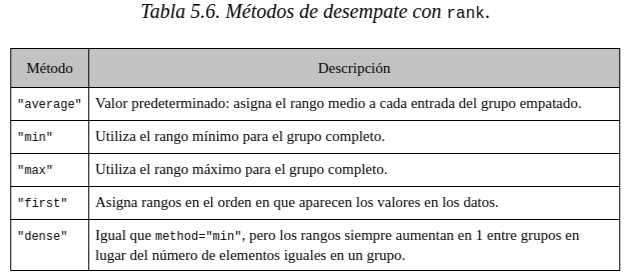

###**Indices de ejes con etiquetas duplicadas**

In [80]:
# Series con indeces duplicados
obj = pd.Series(np.arange(5), index=["a", "a", "b", "b", "c"])
obj


,0
a,0
a,1
b,2
b,3
c,4


In [81]:
obj['a']

,0
a,0
a,1


In [82]:
# dataframe
df = pd.DataFrame(np.random.randn(5, 3), index=["a", "a", "b", "b", "c"])
df

,0,1,2
a,-1.229829,0.730176,1.607283
a,-0.472530,-0.121285,-0.160021
b,-2.326237,-1.176494,0.137337
b,-0.041449,0.698816,-0.683818
c,-0.243132,-1.148513,1.308645


In [83]:
df.loc['b']

,0,1,2
b,-2.326237,-1.176494,0.137337
b,-0.041449,0.698816,-0.683818


In [84]:
df.loc['c']

,c
0,-0.243132
1,-1.148513
2,1.308645


##**Resumir y calcular estadísticas descriptivas**



In [85]:
df = pd.DataFrame([[1.4, np.nan], [7.1, -4.5],
                    [np.nan, np.nan], [0.75, -1.3]],
                    index=["a", "b", "c", "d"],
                    columns=["one", "two"])

In [86]:
df


,one,two
a,1.40,NaN
b,7.10,-4.5
c,NaN,NaN
d,0.75,-1.3


In [87]:
df.sum()

,0
one,9.25
two,-5.80


In [88]:
df.sum(axis='columns')

,0
a,1.40
b,2.60
c,0.00
d,-0.55


In [89]:
# como podemos ver en las sumas de filas o columnas con valores faltantes los asume como 0, esto se puede evitar con el argumento `skipna`
df.sum(axis='index', skipna=False)

,0
one,NaN
two,NaN


In [90]:
df.sum(axis='columns', skipna=False)

,0
a,NaN
b,2.60
c,NaN
d,-0.55


In [91]:
# para el metodo mean se descarta los valores nulo (en fila o columna) y devuelve NaN si todos los valores son nulos
df.mean(axis='columns')

,0
a,1.400
b,1.300
c,NaN
d,-0.275


In [92]:
df.mean(axis='index')

,0
one,3.083333
two,-2.900000


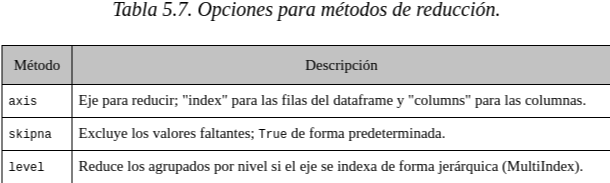

In [93]:
# para obtener los indices con los valores minimos y maximos se utiliza idmin() idmax()
print(df)
df.idxmax()

    one  two
a  1.40  NaN
b  7.10 -4.5
c   NaN  NaN
d  0.75 -1.3


,0
one,b
two,d


In [94]:
# metodos de acumulacion cumsum()
df.cumsum()


,one,two
a,1.40,NaN
b,8.50,-4.5
c,NaN,NaN
d,9.25,-5.8


In [95]:
# metodo describe()
df.describe()

,one,two
count,3.000000,2.000000
mean,3.083333,-2.900000
std,3.493685,2.262742
min,0.750000,-4.500000
25%,1.075000,-3.700000
50%,1.400000,-2.900000
75%,4.250000,-2.100000
max,7.100000,-1.300000


In [96]:
# para datos no numericos trae otras estadisticas
obj = pd.Series(['a','a','b','c']*4)
obj.describe()

,0
count,16
unique,3
top,a
freq,8


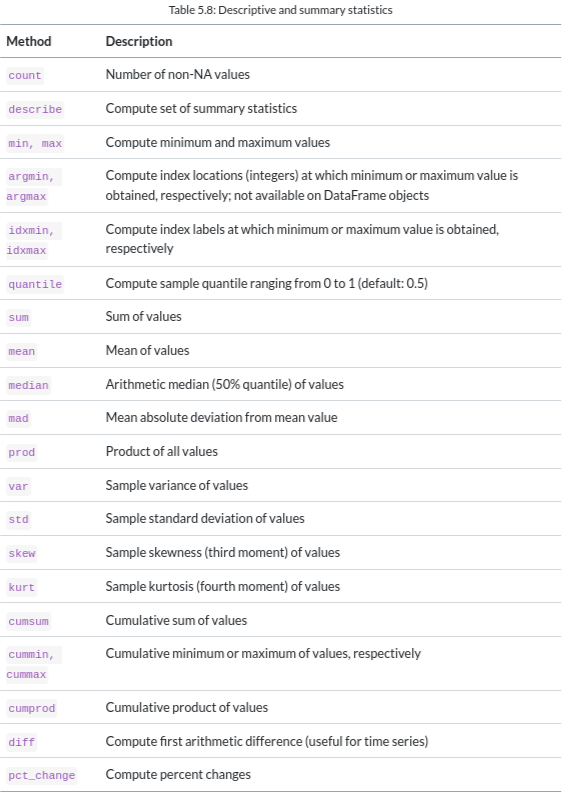

###**Correlacion y covarianza**


In [97]:
price = pd.read_pickle('/content/drive/MyDrive/Colab Notebooks/Libro_Python_para_analisis_de_datos/examples/yahoo_price.pkl')
volume = pd.read_pickle('/content/drive/MyDrive/Colab Notebooks/Libro_Python_para_analisis_de_datos/examples/yahoo_volume.pkl')
returns = price.pct_change()
returns.tail()

,AAPL,GOOG,IBM,MSFT
Date,,,,
2016-10-17,-0.000680,0.001837,0.002072,-0.003483
2016-10-18,-0.000681,0.019616,-0.026168,0.007690
2016-10-19,-0.002979,0.007846,0.003583,-0.002255
2016-10-20,-0.000512,-0.005652,0.001719,-0.004867
2016-10-21,-0.003930,0.003011,-0.012474,0.042096


In [98]:
# calcular la correlacion entre dos serie o columnas del dataframe
print(f'''Correlacion entre MSFT e IBM: {returns['MSFT'].corr(returns['IBM']):.6f}
''')
returns.corr()

Correlacion entre MSFT e IBM: 0.499764



,AAPL,GOOG,IBM,MSFT
AAPL,1.000000,0.407919,0.386817,0.389695
GOOG,0.407919,1.000000,0.405099,0.465919
IBM,0.386817,0.405099,1.000000,0.499764
MSFT,0.389695,0.465919,0.499764,1.000000


In [99]:
# calcular la covarianza entre dos serie o columnas del dataframe
print(f'''Covarianza entre MSFT e IBM: {returns['MSFT'].cov(returns['IBM']):.6f}
''')
returns.cov()

Covarianza entre MSFT e IBM: 0.000089



,AAPL,GOOG,IBM,MSFT
AAPL,0.000277,0.000107,0.000078,0.000095
GOOG,0.000107,0.000251,0.000078,0.000108
IBM,0.000078,0.000078,0.000146,0.000089
MSFT,0.000095,0.000108,0.000089,0.000215


In [100]:
# corrwith() es para correlacionar una serie contra un dataframe
returns.corrwith(returns['IBM'])

,0
AAPL,0.386817
GOOG,0.405099
IBM,1.000000
MSFT,0.499764


In [101]:
# correlacionar un dataframe contra otro siempre y cuando tengan las mismas columnas
df = pd.DataFrame(np.random.randn(50, 4), columns=["a", "b", "c", "d"])
returns.corrwith(volume)

,0
AAPL,-0.075565
GOOG,-0.007067
IBM,-0.204849
MSFT,-0.092950


###**Valores únicos, recuentos de valores y pertenencia**

In [102]:
# metodo unique() devuelve los valores unicos en una serie no ordenados por el orden de aparicion
obj = pd.Series(['c', 'a', 'd', 'a', 'a', 'b', 'b', 'c', 'c'])
uniques = obj.unique()
print(uniques)

# para ordenar la serie usamos la funcion sorted()
print(sorted(uniques))
uniques

['c' 'a' 'd' 'b']
['a', 'b', 'c', 'd']


array(['c', 'a', 'd', 'b'], dtype=object)

In [103]:
# para saber la frecuencia de cada valor
obj.value_counts()

,count
c,3
a,3
b,2
d,1


In [104]:
# para obtener un subconjunto de valores de una serie o dataframe isin()
mask = obj.isin(['b', 'c'])
print(mask)
obj[mask]

0     True
1    False
2    False
3    False
4    False
5     True
6     True
7     True
8     True
dtype: bool


,0
0,c
5,b
6,b
7,c
8,c


In [105]:
# para saber los indeces de los valores segun un array con valores unicos
to_match = pd.Series(["c", "a", "b", "b", "c", "a"])
unique_vals = pd.Series(["c", "d", "a"])
print(f'''to_match
{to_match}
      ''')
print(f'''unique_vals:
{unique_vals}
      ''')
index_unique_vals = pd.Index(unique_vals)
print(f'''index_unique_vals:
{index_unique_vals}
      ''')
indices = index_unique_vals.get_indexer(to_match)
print(f'''indices:
{indices}
      ''')


to_match
0    c
1    a
2    b
3    b
4    c
5    a
dtype: object
      
unique_vals:
0    c
1    d
2    a
dtype: object
      
index_unique_vals:
Index(['c', 'd', 'a'], dtype='object')
      
indices:
[ 0  2 -1 -1  0  2]
      


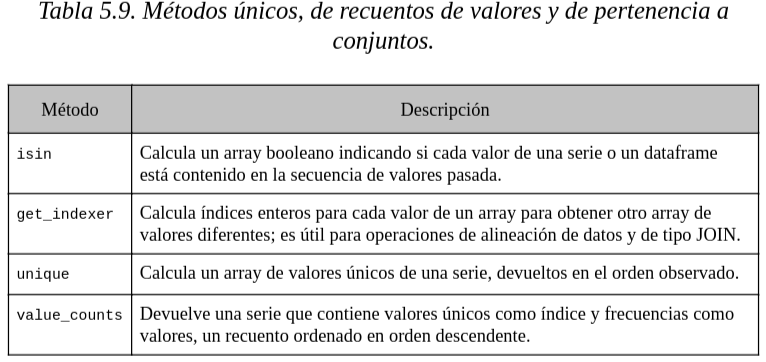

In [106]:
data = pd.DataFrame({"Qu1": [1, 3, 4, 3, 4],
                     "Qu2": [2, 3, 1, 2, 3],
                     "Qu3": [1, 5, 2, 4, 4]})
data

,Qu1,Qu2,Qu3
0,1,2,1
1,3,3,5
2,4,1,2
3,3,2,4
4,4,3,4


In [110]:
# para calcular la frecuancia de valores en una columna del dataframe ordenados por el index
data['Qu1'].value_counts().sort_index()

,count
Qu1,
4,2
3,2
1,1


In [115]:
# Ahora para todas las columnas del dataframe usamos apply
result = data.apply(lambda x: x.value_counts()).fillna(0).astype(int) # sin astype los conteos seran en float y se usa una funcion lambda para acceder a la funcion value_counts()
result

,Qu1,Qu2,Qu3
1,1,1,1
2,0,2,1
3,2,2,0
4,2,0,2
5,0,0,1


In [124]:
data = pd.DataFrame({'a': [1, 1, 1, 2, 2], 'b':
[0, 0, 1, 0, 0]})
print(f'''data:
{data}
      ''')
print(f'''data.value_counts:
{data.value_counts()}
      ''')
data.value_counts()

data: 
   a  b
0  1  0
1  1  0
2  1  1
3  2  0
4  2  0
      
data.value_counts: 
a  b
1  0    2
2  0    2
1  1    1
Name: count, dtype: int64
      


,,count
a,b,
1,0,2
2,0,2
1,1,1


In [126]:
push('finalizado el capitulo 5')

✅ Push realizado correctamente.
